# Timeseries forecasting for weather prediction

**Originally Authored by:** [Prabhanshu Attri](https://prabhanshu.com/github), [Yashika Sharma](https://github.com/yashika51), [Kristi Takach](https://github.com/ktakattack), [Falak Shah](https://github.com/falaktheoptimist)<br>
**Modified by:** [Erem Ozdemir](https://github.com/eremozdemir)<br>

**Date created:** 2020/06/23<br>
**Last modified:** 2026/04/09<br>
**Description:** This notebook demonstrates how to do timeseries forecasting using a LSTM model, and applies three model improvement experiments.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras

## Climate Data Time-Series

We will be using Jena Climate dataset recorded by the
[Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/wetter/).
The dataset consists of 14 features such as temperature, pressure, humidity etc, recorded once per
10 minutes.

**Location**: Weather Station, Max Planck Institute for Biogeochemistry
in Jena, Germany

**Time-frame Considered**: Jan 10, 2009 - December 31, 2016


The table below shows the column names, their value formats, and their description.

Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

In [2]:
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

## Raw Data Visualization

To give us a sense of the data we are working with, each feature has been plotted below.
This shows the distinct pattern of each feature over the time period from 2009 to 2016.
It also shows where anomalies are present, which will be addressed during normalization.

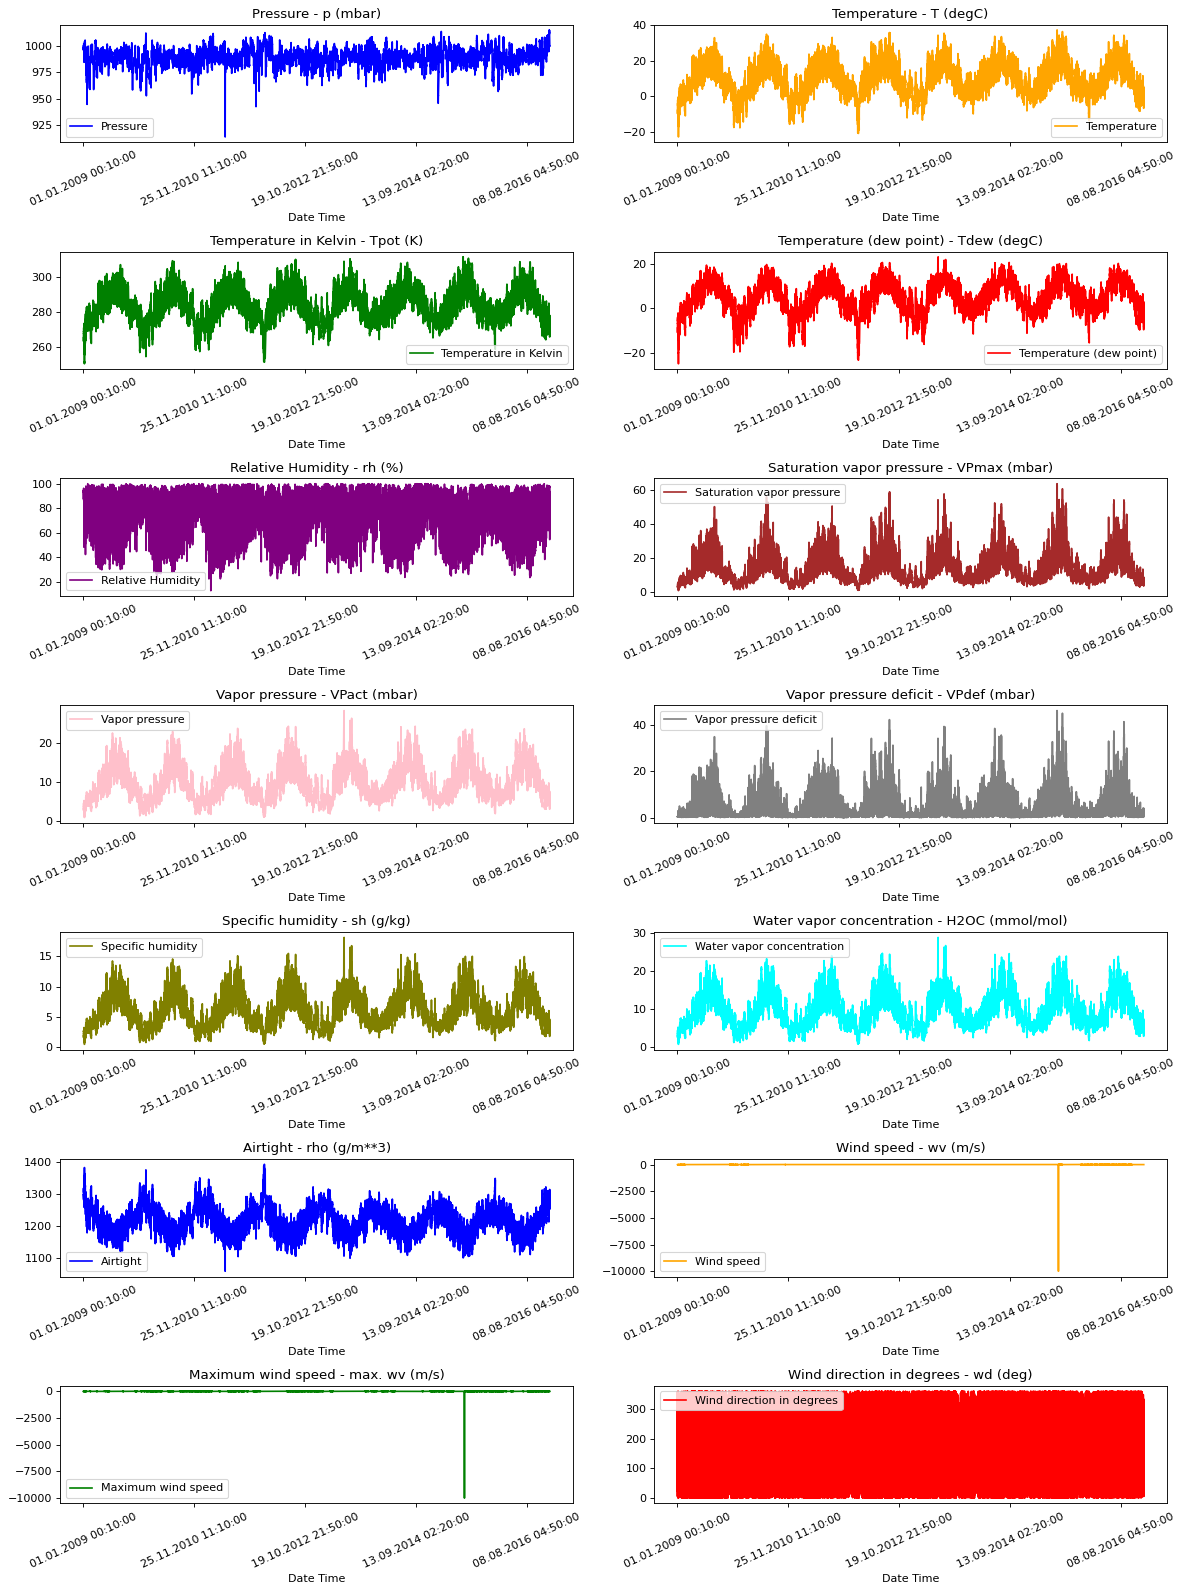

In [3]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

date_time_key = "Date Time"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()


show_raw_visualization(df)

## Data Preprocessing

Here we are picking ~300,000 data points for training. Observation is recorded every
10 mins, that means 6 times per hour. We will resample one point per hour since no
drastic change is expected within 60 minutes. We do this via the `sampling_rate`
argument in `timeseries_dataset_from_array` utility.

We are tracking data from past 720 timestamps (720/6=120 hours). This data will be
used to predict the temperature after 72 timestamps (72/6=12 hours).

Since every feature has values with
varying ranges, we do normalization to confine feature values to a range of `[0, 1]` before
training a neural network.
We do this by subtracting the mean and dividing by the standard deviation of each feature.

71.5 % of the data will be used to train the model, i.e. 300,693 rows. `split_fraction` can
be changed to alter this percentage.

The model is shown data for first 5 days i.e. 720 observations, that are sampled every
hour. The temperature after 72 (12 hours * 6 observation per hour) observation will be
used as a label.

In [4]:
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))
step = 6

past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10


def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

We can see from the correlation heatmap, few parameters like Relative Humidity and
Specific Humidity are redundant. Hence we will be using select features, not all.

In [5]:
print(
    "The selected parameters are:",
    ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]

The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


# Training dataset

The training dataset labels starts from the 792nd observation (720 + 72).

In [6]:
start = past + future
end = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

The `timeseries_dataset_from_array` function takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as length of the
sequences/windows, spacing between two sequence/windows, etc., to produce batches of
sub-timeseries inputs and targets sampled from the main timeseries.

In [7]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

## Validation dataset

The validation dataset must not contain the last 792 rows as we won't have label data for
those records, hence 792 must be subtracted from the end of the data.

The validation label dataset must start from 792 after train_split, hence we must add
past + future (792) to label_start.

In [8]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)


for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


## Training

In [9]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out = keras.layers.LSTM(32)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

We'll use the `ModelCheckpoint` callback to regularly save checkpoints, and
the `EarlyStopping` callback to interrupt training when the validation loss
is not longer improving.

In [10]:
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)

modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

# Baseline Result Log
_val = history.history["val_loss"]
baseline_best_val_loss = min(_val)
_best_ep = _val.index(baseline_best_val_loss) + 1
_epochs_run = len(_val)

print("\n" + "=" * 50)
print("  BASELINE LSTM RESULTS")
print("=" * 50)
print(f"  Best Val Loss (MSE):    {baseline_best_val_loss:.4f}  (epoch {_best_ep}/{_epochs_run})")
print(f"  Final Train Loss (MSE): {history.history['loss'][-1]:.4f}")
print(f"  Epochs run:             {_epochs_run}")
print("=" * 50)


Epoch 1/10
1170/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3162
Epoch 1: val_loss improved from None to 0.14825, saving model to model_checkpoint.weights.h5

Epoch 1: finished saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - loss: 0.1846 - val_loss: 0.1482
Epoch 2/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1417
Epoch 2: val_loss improved from 0.14825 to 0.14153, saving model to model_checkpoint.weights.h5

Epoch 2: finished saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 0.1236 - val_loss: 0.1415
Epoch 3/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1216
Epoch 3: val_loss did not improve from 0.14153
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.1133 - val_loss: 0.1503
Epoch 4/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1177
Epoch 4: val_loss did not improve from 0.14153
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - loss: 0.1097 - val_loss: 0.

We can visualize the loss with the function below. After one point, the loss stops
decreasing.

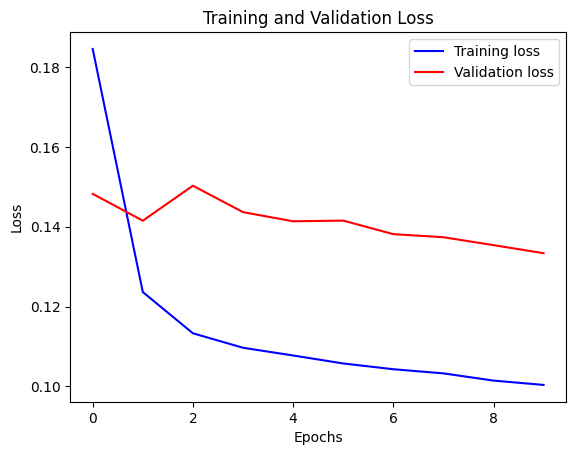

In [11]:
def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


visualize_loss(history, "Training and Validation Loss")

## Prediction

The trained model above is now able to make predictions for 5 sets of values from
validation set.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


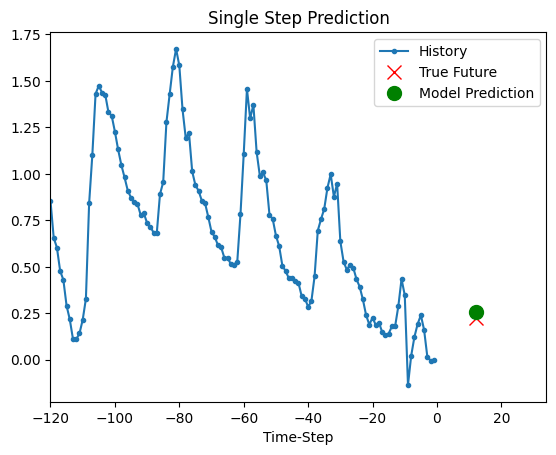

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


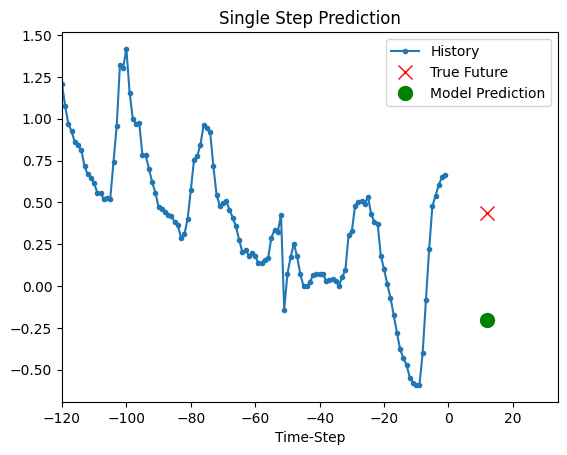

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


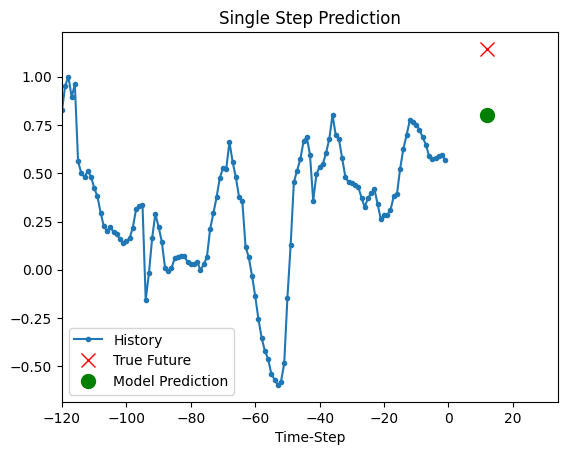

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


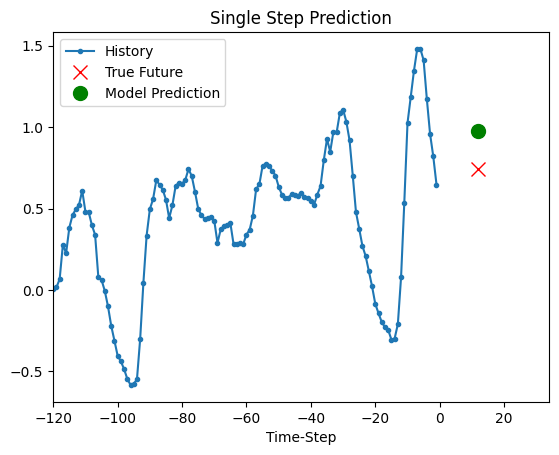

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


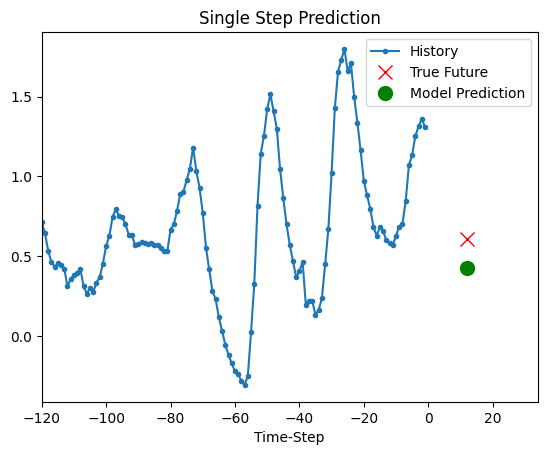

In [12]:
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return


for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )

---

## Improvement Experiments

Four controlled modifications are applied to the baseline LSTM model, **one at a time**, to isolate each effect. All other hyperparameters remain identical to the baseline unless stated.

| Experiment | Modification | Rationale |
|---|---|---|
| 1 | More epochs (10 → 50) | Establish a proper training budget before comparing architectures |
| 2 | Stacked LSTM (32 → 32) | Learn higher-order temporal abstractions |
| 3 | Larger hidden size (32 → 64) | More capacity to encode 7-feature sequences |
| 4 | Lower learning rate (0.001 → 0.0005) | More stable gradient descent near the optimum |

**Note:** Experiments 2–4 all use a max `epochs_exp = 50` (same budget as Experiment 1) so results are comparable and not skewed by the 10-epoch ceiling.

The datasets (`dataset_train`, `dataset_val`) and all preprocessing are shared with the baseline above.


### Experiment 1: Extended Training (More Epochs)

**Change:** Increase training budget from `epochs=10` → `epochs_exp=50` (same LSTM(32) baseline architecture, same learning rate).

The original 10-epoch budget was set for quick demonstration. In my first run of the experiments, some were still improving at epoch 10, meaning results were cut off before convergence. This experiment establishes the same model given a proper training budget, with early stopping (patience=5) to prevent overfitting.

**Parameters:** same as baseline (5153 parameters)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2793
Epoch 1: val_loss improved from None to 0.17568, saving model to model_exp1.weights.h5

Epoch 1: finished saving model to model_exp1.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.1905 - val_loss: 0.1757
Epoch 2/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1480
Epoch 2: val_loss improved from 0.17568 to 0.14934, saving model to model_exp1.weights.h5

Epoch 2: finished saving model to model_exp1.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.1290 - val_loss: 0.1493
Epoch 3/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1283
Epoch 3: val_loss did not improve from 0.14934
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.1160 - val_loss: 0.1523
Epoch 4/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1178
Epoch 4: val_loss improved from 0.14934 to 0.14661, saving model to model_exp1.weights.h5

Epoch 4: finished saving model to model_exp1.weights.h

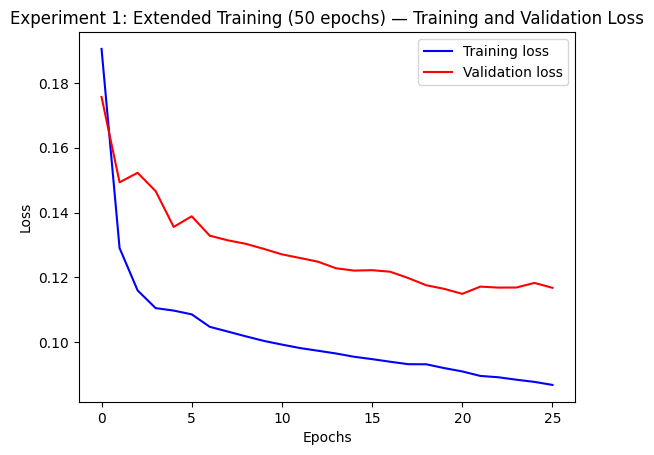


  EXP 1: EXTENDED TRAINING RESULTS
  Best Val Loss (MSE):  0.1149  (epoch 21/26)
  Baseline (10 ep):     0.1334
  Change:               -13.8%  (improvement)


In [13]:
epochs_exp = 50  # shared budget for all experiments

inputs_exp1 = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out_exp1 = keras.layers.LSTM(32)(inputs_exp1)
outputs_exp1 = keras.layers.Dense(1)(lstm_out_exp1)

model_exp1 = keras.Model(inputs=inputs_exp1, outputs=outputs_exp1)
model_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse"
)
model_exp1.summary()

es_exp1 = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
ckpt_exp1 = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath="model_exp1.weights.h5",
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp1 = model_exp1.fit(
    dataset_train,
    epochs=epochs_exp,
    validation_data=dataset_val,
    callbacks=[es_exp1, ckpt_exp1],
)

visualize_loss(history_exp1, "Experiment 1: Extended Training (50 epochs) — Training and Validation Loss")

# Experiment 1 Result Log
_val1 = history_exp1.history["val_loss"]
exp1_best_val_loss = min(_val1)
_best_ep1 = _val1.index(exp1_best_val_loss) + 1
_epochs1 = len(_val1)
_delta1 = (exp1_best_val_loss - baseline_best_val_loss) / baseline_best_val_loss * 100

print("\n" + "=" * 55)
print("  EXP 1: EXTENDED TRAINING RESULTS")
print("=" * 55)
print(f"  Best Val Loss (MSE):  {exp1_best_val_loss:.4f}  (epoch {_best_ep1}/{_epochs1})")
print(f"  Baseline (10 ep):     {baseline_best_val_loss:.4f}")
print(f"  Change:               {_delta1:+.1f}%  ({'improvement' if _delta1 < 0 else 'WORSE'})")
print("=" * 55)


### Experiment 2: Stacked LSTM (Two Layers)

**Change:** Replace `LSTM(32)` with `LSTM(32, return_sequences=True)` → `LSTM(32)` (using `epochs_exp=50`).

A second LSTM layer allows the model to learn higher-order temporal abstractions. The first layer produces a sequence of hidden states (one per timestep), and the second layer summarises patterns across those states, to capture dependencies between temporal patterns.

**Parameters added:** ~8k (from 5153 to 13 473 total)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 120, 32)        │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,473 (52.63 KB)

 Trainable params: 13,473 (52.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3901
Epoch 1: val_loss improved from None to 0.16928, saving model to model_exp2.weights.h5

Epoch 1: finished saving model to model_exp2.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - loss: 0.2064 - val_loss: 0.1693
Epoch 2/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1465
Epoch 2: val_loss improved from 0.16928 to 0.14829, saving model to model_exp2.weights.h5

Epoch 2: finished saving model to model_exp2.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 54s 46ms/step - loss: 0.1281 - val_loss: 0.1483
Epoch 3/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1297
Epoch 3: val_loss improved from 0.14829 to 0.14002, saving model to model_exp2.weights.h5

Epoch 3: finished saving model to model_exp2.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 54s 46ms/step - loss: 0.1183 - val_loss: 0.1400
Epoch 4/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1232
Epoch 4: val_loss improved from 0.14002 to 0.

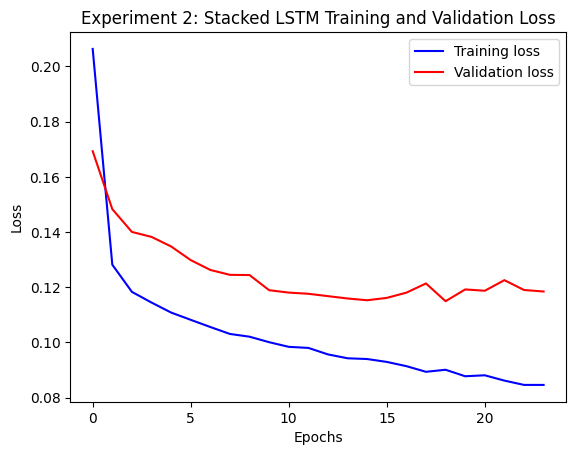


  EXP 2: STACKED LSTM RESULTS
  Best Val Loss (MSE):  0.1149  (epoch 19/24)
  Baseline:             0.1334
  Change:               -13.8%  (improvement)


In [14]:
inputs_exp2 = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
x = keras.layers.LSTM(32, return_sequences=True)(inputs_exp2)
lstm_out_exp2 = keras.layers.LSTM(32)(x)
outputs_exp2 = keras.layers.Dense(1)(lstm_out_exp2)

model_exp2 = keras.Model(inputs=inputs_exp2, outputs=outputs_exp2)
model_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse"
)
model_exp2.summary()

es_exp2 = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
ckpt_exp2 = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath="model_exp2.weights.h5",
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp2 = model_exp2.fit(
    dataset_train,
    epochs=epochs_exp,
    validation_data=dataset_val,
    callbacks=[es_exp2, ckpt_exp2],
)

visualize_loss(history_exp2, "Experiment 2: Stacked LSTM Training and Validation Loss")

# Experiment 2 Result Log
_val2 = history_exp2.history["val_loss"]
exp2_best_val_loss = min(_val2)
_best_ep2 = _val2.index(exp2_best_val_loss) + 1
_epochs2 = len(_val2)
_delta2 = (exp2_best_val_loss - baseline_best_val_loss) / baseline_best_val_loss * 100

print("\n" + "=" * 55)
print("  EXP 2: STACKED LSTM RESULTS")
print("=" * 55)
print(f"  Best Val Loss (MSE):  {exp2_best_val_loss:.4f}  (epoch {_best_ep2}/{_epochs2})")
print(f"  Baseline:             {baseline_best_val_loss:.4f}")
print(f"  Change:               {_delta2:+.1f}%  ({'improvement' if _delta2 < 0 else 'WORSE'})")
print("=" * 55)


### Experiment 3: Larger Hidden Size

**Change:** Increase LSTM units from 32 → 64 (single layer, using `epochs_exp=50`).

A larger hidden state gives the model more capacity to encode the 7-feature input over 120 timesteps. With only 32 units, the hidden state may be a bottleneck when compressing this multi-variate sequence into a single vector for prediction. With 50 epochs, this model has enough budget to actually converge rather than being cut off early.

**Parameters:** 18 497 (vs 5153 baseline)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2685
Epoch 1: val_loss improved from None to 0.14753, saving model to model_exp3.weights.h5

Epoch 1: finished saving model to model_exp3.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 53s 45ms/step - loss: 0.1618 - val_loss: 0.1475
Epoch 2/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1381
Epoch 2: val_loss did not improve from 0.14753
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 52s 45ms/step - loss: 0.1257 - val_loss: 0.1535
Epoch 3/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1264
Epoch 3: val_loss did not improve from 0.14753
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 52s 45ms/step - loss: 0.1169 - val_loss: 0.1585
Epoch 4/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1230
Epoch 4: val_loss did not improve from 0.14753
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 52s 44ms/step - loss: 0.1129 - val_loss: 0.1587
Epoch 5/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1214
Epoch 5: val_loss did not improve from 0.14753
11

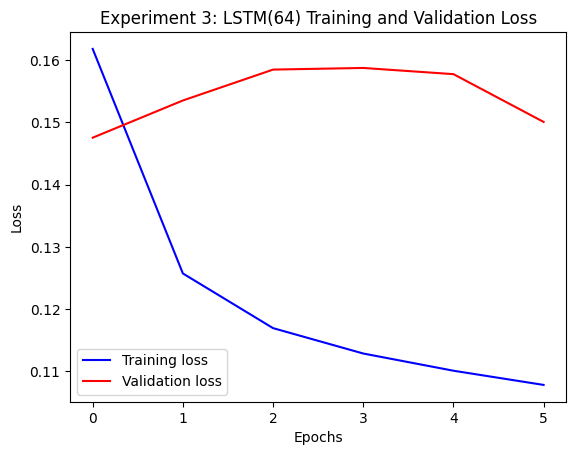


  EXP 3: LSTM(64) RESULTS
  Best Val Loss (MSE):  0.1475  (epoch 1/6)
  Baseline:             0.1334
  Change:               +10.6%  (WORSE)


In [15]:
inputs_exp3 = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out_exp3 = keras.layers.LSTM(64)(inputs_exp3)
outputs_exp3 = keras.layers.Dense(1)(lstm_out_exp3)

model_exp3 = keras.Model(inputs=inputs_exp3, outputs=outputs_exp3)
model_exp3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse"
)
model_exp3.summary()

es_exp3 = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
ckpt_exp3 = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath="model_exp3.weights.h5",
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp3 = model_exp3.fit(
    dataset_train,
    epochs=epochs_exp,
    validation_data=dataset_val,
    callbacks=[es_exp3, ckpt_exp3],
)

visualize_loss(history_exp3, "Experiment 3: LSTM(64) Training and Validation Loss")

# Result Log
_val3 = history_exp3.history["val_loss"]
exp3_best_val_loss = min(_val3)
_best_ep3 = _val3.index(exp3_best_val_loss) + 1
_epochs3 = len(_val3)
_delta3 = (exp3_best_val_loss - baseline_best_val_loss) / baseline_best_val_loss * 100

print("\n" + "=" * 55)
print("  EXP 3: LSTM(64) RESULTS")
print("=" * 55)
print(f"  Best Val Loss (MSE):  {exp3_best_val_loss:.4f}  (epoch {_best_ep3}/{_epochs3})")
print(f"  Baseline:             {baseline_best_val_loss:.4f}")
print(f"  Change:               {_delta3:+.1f}%  ({'improvement' if _delta3 < 0 else 'WORSE'})")
print("=" * 55)


### Experiment 4: Reduced Learning Rate

**Change:** Lower the Adam learning rate from 0.001 to 0.0005 (baseline architecture, using `epochs_exp=50`).

A smaller learning rate means each gradient step is more conservative. This can help the optimizer settle into a better minimum rather than oscillating around it. With 50 epochs available, the slower convergence speed is no longer a disadvantage and thus the model has enough budget to reach a good optimum.

**Parameters:** same as baseline (5153 parameters)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4010
Epoch 1: val_loss improved from None to 0.13874, saving model to model_exp4.weights.h5

Epoch 1: finished saving model to model_exp4.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 0.2331 - val_loss: 0.1387
Epoch 2/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1470
Epoch 2: val_loss improved from 0.13874 to 0.12185, saving model to model_exp4.weights.h5

Epoch 2: finished saving model to model_exp4.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - loss: 0.1281 - val_loss: 0.1219
Epoch 3/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1236
Epoch 3: val_loss improved from 0.12185 to 0.11916, saving model to model_exp4.weights.h5

Epoch 3: finished saving model to model_exp4.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step - loss: 0.1151 - val_loss: 0.1192
Epoch 4/50
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1178
Epoch 4: val_loss improved from 0.11916 to 0.

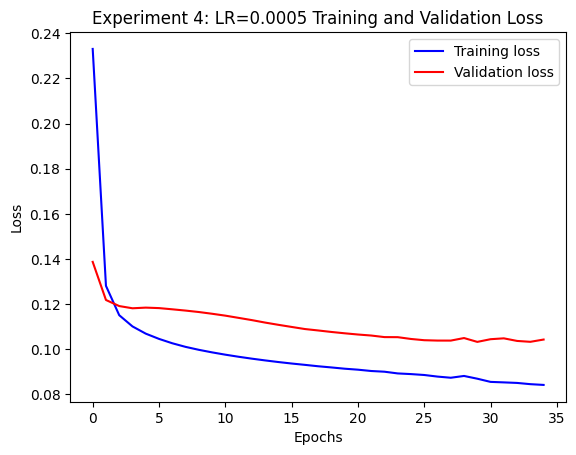


  EXP 4: LR=0.0005 RESULTS
  Best Val Loss (MSE):  0.1033  (epoch 30/35)
  Baseline:             0.1334
  Change:               -22.6%  (improvement)


In [16]:
inputs_exp4 = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out_exp4 = keras.layers.LSTM(32)(inputs_exp4)
outputs_exp4 = keras.layers.Dense(1)(lstm_out_exp4)

model_exp4 = keras.Model(inputs=inputs_exp4, outputs=outputs_exp4)
model_exp4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss="mse"
)
model_exp4.summary()

es_exp4 = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
ckpt_exp4 = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath="model_exp4.weights.h5",
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp4 = model_exp4.fit(
    dataset_train,
    epochs=epochs_exp,
    validation_data=dataset_val,
    callbacks=[es_exp4, ckpt_exp4],
)

visualize_loss(history_exp4, "Experiment 4: LR=0.0005 Training and Validation Loss")

# Result Log
_val4 = history_exp4.history["val_loss"]
exp4_best_val_loss = min(_val4)
_best_ep4 = _val4.index(exp4_best_val_loss) + 1
_epochs4 = len(_val4)
_delta4 = (exp4_best_val_loss - baseline_best_val_loss) / baseline_best_val_loss * 100

print("\n" + "=" * 55)
print("  EXP 4: LR=0.0005 RESULTS")
print("=" * 55)
print(f"  Best Val Loss (MSE):  {exp4_best_val_loss:.4f}  (epoch {_best_ep4}/{_epochs4})")
print(f"  Baseline:             {baseline_best_val_loss:.4f}")
print(f"  Change:               {_delta4:+.1f}%  ({'improvement' if _delta4 < 0 else 'WORSE'})")
print("=" * 55)


## Benchmark Comparison Summary


In [17]:
# Benchmark Comparison Table
results = [
    ("Baseline", "LSTM(32), lr=0.001",          baseline_best_val_loss, "5153",  len(history.history["val_loss"])),
    ("Exp 1",    "Extended training (50 ep)",    exp1_best_val_loss,     "5153",  len(history_exp1.history["val_loss"])),
    ("Exp 2",    "Stacked LSTM (32→32)",          exp2_best_val_loss,     "13 473", len(history_exp2.history["val_loss"])),
    ("Exp 3",    "LSTM(64), lr=0.001",            exp3_best_val_loss,     "18 497", len(history_exp3.history["val_loss"])),
    ("Exp 4",    "LSTM(32), lr=0.0005",           exp4_best_val_loss,     "5153",  len(history_exp4.history["val_loss"])),
]

best_loss = min(r[2] for r in results)

print("\n" + "=" * 72)
print("  LSTM EXPERIMENT BENCHMARK - Jena Climate (Val Loss = MSE, normalized)")
print("=" * 72)
print(f"  {'Experiment':<12} {'Modification':<30} {'Val Loss':>9}  {'Change':>8}  {'Params':>6}  {'Epochs':>6}")
print("-" * 72)
for name, mod, val_loss, params, ep in results:
    delta = (val_loss - baseline_best_val_loss) / baseline_best_val_loss * 100
    delta_str = "baseline" if name == "Baseline" else f"{delta:+.1f}%"
    marker = " ◀ best" if val_loss == best_loss else ""
    print(f"  {name:<12} {mod:<30} {val_loss:>9.4f}  {delta_str:>8}  {params:>6}  {ep:>6}{marker}")
print("=" * 72)
print(f"\n  Best result: {min(results, key=lambda r: r[2])[0]} — {min(results, key=lambda r: r[2])[1]}")



  LSTM EXPERIMENT BENCHMARK - Jena Climate (Val Loss = MSE, normalized)
  Experiment   Modification                    Val Loss    Change  Params  Epochs
------------------------------------------------------------------------
  Baseline     LSTM(32), lr=0.001                0.1334  baseline    5153      10
  Exp 1        Extended training (50 ep)         0.1149    -13.8%    5153      26
  Exp 2        Stacked LSTM (32→32)              0.1149    -13.8%  13 473      24
  Exp 3        LSTM(64), lr=0.001                0.1475    +10.6%  18 497       6
  Exp 4        LSTM(32), lr=0.0005               0.1033    -22.6%    5153      35 ◀ best

  Best result: Exp 4 — LSTM(32), lr=0.0005
